# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Abdul-Salam Gidado

**Date:** Sep 5, 2026

### Question 1 Part 1

In [ ]:
!pip install pandas
!pip install matplotlib

In [ ]:
import pandas as pd
data = pd.read_csv("data/airbnb_hw.csv")
print("First 20 values of the 'Price' column:")
print(data["Price"].head(20))

print("The Data Type of the 'Price' column:")
print(data["Price"].dtype)

print(f"Missing values: {data['Price'].isna().sum()}")

print("Value counts of the 'Price' column (top 20):")
data["Price"].value_counts().tail(20)

Based on my investigation, I realized that the 'Price' column is the str datatype. For prices that are above 999, the value contains a column. So my solution would involved removing the comma with a an empty string. Then I can cleanly convert the 'Price' column from the str datatype to the int datatype.

In [ ]:
# Replace commas in the 'Price' column with an empty string
data["Price"] = data["Price"].str.replace(',', '')

# Convert the 'Price' column to int
data["Price"] = pd.to_numeric(data["Price"])

#Results
print(f"Data type: {data['Price'].dtype}")
print(f"Missing values: {data['Price'].isna().sum()}")
print(f"\nFirst 20 values:")
print(data["Price"].head(20))
print(data["Price"].describe())

### Question 1 Part 2

In [ ]:
data2 = pd.read_csv("data/mn_police_use_of_force.csv")
print(f"Missing values in 'subject_injury': {data2['subject_injury'].isna().sum()}")
print(f"Proportion of missing values in 'subject_injury': {(data2['subject_injury'].isna().sum() / len(data2))*100}%")
print(data2['subject_injury'].value_counts())

data2[['subject_injury', 'force_type']].head()

Based on my initial look at the 'subject_injury' and the 'force_type' column, I realized that the the 'subject_injury column has many missing values. Approxiametely 76 percent of this column are missing values. Since the goal is to find the meaning behind this missing values, cross tabulating does not work at this moment because the missing value is not a unique value that is counted. So the solution I would use is to fill the missing value. 

In [ ]:
#fill missing values in the 'subject_injury' column with 'Missing'
data2['subject_injury'] = data2['subject_injury'].fillna('Missing')
print(data2[['subject_injury', 'force_type']].head())

#Perform the crosstab analysis
crosstab = pd.crosstab(data2['subject_injury'], data2['force_type'])
print(crosstab)

crosstab_analysis = pd.DataFrame(
    index=crosstab.columns,
    columns=['Frequency_Missing']
)
crosstab_analysis['Frequency_Missing'] = (crosstab.loc['Missing'].values)
print(crosstab_analysis)


After filling the missing values with the string 'Missing', I am able to see the relationship between the missing values in 'subject_injury" and force type using the cross tab. I am noticing that bodily force, chemical irritant, and maximal restraint technique of most, if not all, values as missing, which is an interesting observation. 

### Question 2
Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

In [ ]:
#Load the data
shark_df = pd.read_csv("data/GSAF5.csv", encoding="latin-1")

#Remove Empty Columns
shark_df = shark_df.dropna(axis=1, how='all')
shark_df = shark_df.drop(columns = ['Unnamed: 21', 'Unnamed: 22'])

#Display basic information about the dataframe
print(shark_df.head())
print(shark_df.info())
print(shark_df.describe())
print(shark_df.columns)

In [ ]:
shark_df['Year'].describe()

After cleaning the year column, the range of values that I see are from 0 to 2026. I doubt this data has been tracking shark attacks since the beginning of time.

In [ ]:
shark_df_filter = shark_df.loc[shark_df['Year'] >= 1940]
print(shark_df_filter.head())
plt.hist(shark_df_filter['Year'], bins=20, edgecolor='black')
plt.title("Distribution of Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

Based on the graph that I plotted for the number of shark attacks over time, it seems there was a small peak in of shark attacks in the 1960s then a brief drop afterwards. Then the number of attacks have increased over time and peaked in the 2010s. 

In [ ]:
shark_df_filter["Age"].describe()
shark_df_filter["Age_Clean"] = pd.to_numeric(shark_df_filter["Age"], errors='coerce')
shark_df_filter["Age_Clean"].fillna(shark_df_filter["Age_Clean"].median(), inplace=True)
shark_df_filter["Age_Clean"].describe()

In [ ]:
import matplotlib.pyplot as plt
plt.hist(shark_df_filter["Age_Clean"], bins=5, edgecolor='black')
plt.title("Distribution of Age_Clean")
plt.xlabel("Age_Clean")
plt.ylabel("Frequency")

In [ ]:
victim_gender = shark_df_filter["Sex"].value_counts().loc[["M", "F"]]
print(f"The proportion of male victims: {victim_gender['M'] / victim_gender.sum() * 100:.2f}%")
print(f"The proportion of female victims: {victim_gender['F'] / victim_gender.sum() * 100:.2f}%")


The proportion of male victims is 85.73 percent, while the proportion of female victims is 14.27 percent.

In [ ]:
shark_df_filter['Type'].value_counts()
shark_df_filter['Type'] = shark_df_filter['Type'].str.lower()
shark_df_filter['Type'] = shark_df_filter['Type'].replace(['watercraft', 'boat', 'sea disaster'], 'unprovoked')
shark_df_filter['Type'] = shark_df_filter['Type'].replace(['invalid', 'questionable', 'unconfirmed', 'unverified', "?", 'under investigation'], 'unknown')
shark_df_filter['Type'] = shark_df_filter['Type'].replace(' provoked', 'provoked')
shark_df_filter['Type'].value_counts()

In [ ]:
shark_type_freq = shark_df_filter['Type'].value_counts()
print(shark_type_freq)
print(f"The proportion of unprovoked attacks: {shark_type_freq['unprovoked'] / shark_type_freq.sum() * 100:.2f}%")

The proportion of unprovoked attacks is 82.74 percent.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** e3a48ec529c1e44bb3390f94c8b989387911f2e7 and 38ce6e9eb304e32d9ae19aae0ee01ea077d06b56
- **AI tool and model used:** Gemini

### *Prompts used

1. "I want you to evaluate the phase 1 part of this assignment and then provide some suggestions on how to improve my solutions so I can make them more effective and efficient for answering the corresponding questions. Ask me any clarifying questions the you need?"

2. "If you look at the repo again, I got the csv version of the data so that does not apply.The instructor did not specify which NA filling method was required. The directions in jupyter notebook are the only directions given."

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]
1. Standardize string cleaning on `Price` using regex replacement for symbols and commas, coerce via `pd.to_numeric()`, and report null counts accurately without invalid integer conversion.
2. Avoid destructive `'Missing'` imputation in `subject_injury`; pass `dropna=False` and `normalize='columns'` to `pd.crosstab` to evaluate relative missingness rates across force types.
3. Drop empty columns dynamically using `.dropna(how='all', axis=1)` and remove unwanted metadata columns using regex pattern matching on column names rather than hardcoded column lists.
4. Coerce `Year` to numeric, filter records `>= 1940` on an explicit `.copy()` to avoid `SettingWithCopyWarning`, and plot annual attack counts using a continuous line plot to show trend direction clearly.
5. Parse `Age` using regex digit extraction, convert to numeric without median imputation, and visualize using readable bin widths.
6. Clean `Sex` by stripping whitespace and uppercase normalization, reporting both the proportion among known sexes and the overall missingness rate.
7. Map `Type` with a strict categorical function or dictionary that routes all non-matching and ambiguous entries to `'Unknown'`, guaranteeing exactly three output categories.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Handles edge cases cleanly and respects float representation for missing data. Verified by checking `isna().sum()` before and after conversion. |
| 2 | Accept | `dropna=False` avoids mutating the series, while column proportions show true patterns across force types. Verified by comparing counts against `normalize='columns'` output. |
| 3 | Accept | Eliminates hardcoded column names (`Unnamed: 21`, etc.) and prevents whitespace indexing bugs. Verified by inspecting `df.columns`. |
| 4 | Accept | Eliminates `SettingWithCopyWarning` and visualizes annual trends more clearly than coarse histogram bins. Verified by plotting `value_counts().sort_index()`. |
| 5 | Accept | Avoids artificial distributional distortion caused by imputing thousands of unknown ages at a single point. Verified by checking histogram shape without the central spike. |
| 6 | Accept | Standardizes entries like `'M '` and accounts for missing values transparently. Verified by checking `value_counts()` on cleaned series. |
| 7 | Accept | Guarantees compliance with the requirement of exactly three categorical levels (`Provoked`, `Unprovoked`, `Unknown`). Verified by running `.unique()` on the resulting column. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [30]:
# Your Phase 2 solution to the problem goes here.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Question 1 Part 1

In [31]:
airbnb = pd.read_csv("data/airbnb_hw.csv")

# Clean symbols, commas, and trailing whitespace
airbnb["Price_Clean"] = (
    airbnb["Price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)
airbnb["Price_Clean"] = pd.to_numeric(airbnb["Price_Clean"], errors="coerce")

initial_na = airbnb["Price"].isna().sum()
final_na = airbnb["Price_Clean"].isna().sum()

print(f"Initial missing values: {initial_na}")
print(f"Final missing values after cleaning: {final_na}")
print(f"Cleaned column dtype: {airbnb['Price_Clean'].dtype}")
print("\nSummary Statistics:")
print(airbnb["Price_Clean"].describe())

Initial missing values: 0
Final missing values after cleaning: 0
Cleaned column dtype: int64

Summary Statistics:
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price_Clean, dtype: float64


### Question 1 Part 2

In [32]:
police = pd.read_csv("data/mn_police_use_of_force.csv")

# 1. Missing value proportion
missing_injury_prop = police["subject_injury"].isna().mean()
print(f"Proportion of missing values in 'subject_injury': {missing_injury_prop * 100:.2f}%")

# 2. Cross-tabulation: Counts (handling NAs explicitly via fillna for presentation)
crosstab_counts = pd.crosstab(
    police["subject_injury"].fillna("Missing"), 
    police["force_type"], 
    dropna=False
)
print("\nCrosstab: Injury vs Force Type (Counts)")
print(crosstab_counts)

# 3. Cross-tabulation: Column Proportions (rate of missingness within each force type)
crosstab_col_prop = pd.crosstab(
    police["subject_injury"].fillna("Missing"), 
    police["force_type"], 
    normalize="columns"
) * 100
print("\nCrosstab: Injury vs Force Type (Column Percentages)")
print(crosstab_col_prop.round(2))

Proportion of missing values in 'subject_injury': 76.19%

Crosstab: Injury vs Force Type (Counts)
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
Missing             2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
Missing                        27                 74           87   
No                             33                 34            0   
Yes                            44                 40            0   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
Missing                              0                          170   
No     

### Question 2, Parts 1 & 2

In [34]:
# 1. Load CSV data
shark_df = pd.read_csv("data/GSAF5.csv", encoding="latin-1")

# Strip trailing whitespace from column names
shark_df.columns = shark_df.columns.str.strip()

# 2. Drop columns that do not contain data or are unneeded unnamed artifacts
shark_df = shark_df.dropna(axis=1, how="all")
shark_df = shark_df.loc[:, ~shark_df.columns.str.contains(r"^Unnamed")]

print(f"Dataset shape after dropping empty columns: {shark_df.shape}")
print("Remaining columns:", list(shark_df.columns))

Dataset shape after dropping empty columns: (39230, 21)
Remaining columns: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']


/tmp/ipykernel_4515/886309398.py:2: DtypeWarning: Columns (0: Date, 1: Type, 2: Country, 3: State, 4: Location, 5: Activity, 6: Name, 7: Sex, 8: Age, 9: Injury, 10: Fatal Y/N, 11: Time, 12: Species , 13: Source, 14: pdf, 15: href formula, 16: href, 17: Case Number, 18: Case Number.1, 19: Unnamed: 21, 20: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  shark_df = pd.read_csv("data/GSAF5.csv", encoding="latin-1")


### Question 2, Part 3

Full range of Year values: 0.0 to 2026.0


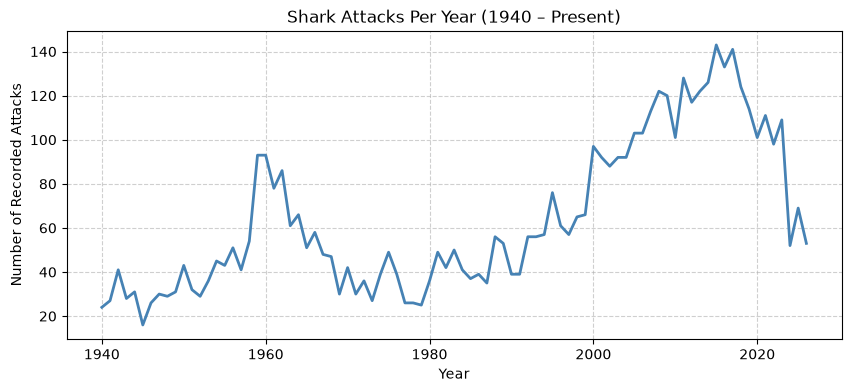

In [35]:
# Clean Year to numeric
shark_df["Year_Clean"] = pd.to_numeric(shark_df["Year"], errors="coerce")

print(f"Full range of Year values: {shark_df['Year_Clean'].min()} to {shark_df['Year_Clean'].max()}")

# Filter to attacks since 1940 using an explicit copy to prevent SettingWithCopyWarning
shark_modern = shark_df[shark_df["Year_Clean"] >= 1940].copy()

# Plot attacks over time using an annual frequency line chart
yearly_counts = shark_modern["Year_Clean"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(yearly_counts.index, yearly_counts.values, color="steelblue", linewidth=2)
plt.title("Shark Attacks Per Year (1940 – Present)")
plt.xlabel("Year")
plt.ylabel("Number of Recorded Attacks")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Question 2, Part 4

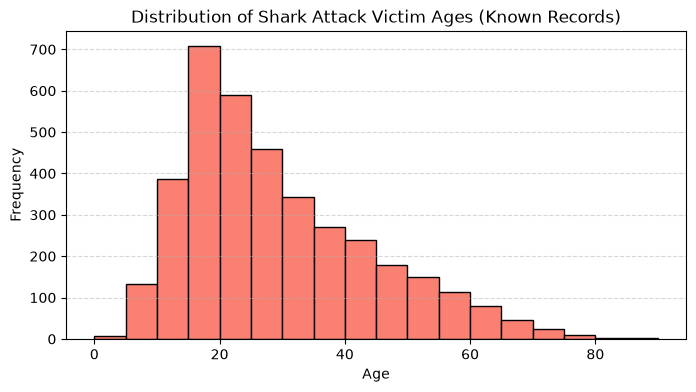

Summary statistics for victim ages:
count    3739.000000
mean       28.637336
std        14.828070
min         1.000000
25%        17.000000
50%        25.000000
75%        38.000000
max        87.000000
Name: Age_Clean, dtype: float64


In [36]:
# Extract initial contiguous digits for entries like '20s', '18 months', etc.
extracted_age = shark_modern["Age"].astype(str).str.extract(r"(\d+)", expand=False)
shark_modern["Age_Clean"] = pd.to_numeric(extracted_age, errors="coerce")

# Filter out missing values (known ages only) to avoid distorting the empirical distribution
known_ages = shark_modern["Age_Clean"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(known_ages, bins=range(0, int(known_ages.max()) + 5, 5), edgecolor="black", color="salmon")
plt.title("Distribution of Shark Attack Victim Ages (Known Records)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print("Summary statistics for victim ages:")
print(known_ages.describe())

### Question 2, Part 5

In [37]:
# Clean Sex variable
sex_clean = shark_modern["Sex"].astype(str).str.strip().str.upper()
sex_mapped = sex_clean.map({"M": "Male", "F": "Female"}).fillna("Unknown/Unrecorded")

# Proportion among known male/female victims
known_sex_mask = sex_clean.isin(["M", "F"])
male_prop_known = (sex_clean == "M").sum() / known_sex_mask.sum() * 100
female_prop_known = (sex_clean == "F").sum() / known_sex_mask.sum() * 100

print(f"Proportion of male victims (among known): {male_prop_known:.2f}%")
print(f"Proportion of female victims (among known): {female_prop_known:.2f}%")

print("\nOverall breakdown including unrecorded:")
print(sex_mapped.value_counts(normalize=True) * 100)

Proportion of male victims (among known): 85.72%
Proportion of female victims (among known): 14.28%

Overall breakdown including unrecorded:
Sex
Male                  78.713492
Female                13.115929
Unknown/Unrecorded     8.170579
Name: proportion, dtype: float64


### Question 2, Part 6

In [38]:
def standardize_type(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).strip().lower()
    if "unprovoked" in val or val in ["boat", "watercraft", "sea disaster"]:
        return "Unprovoked"
    elif "provoked" in val:
        return "Provoked"
    else:
        return "Unknown"

# Standardize to exactly three categories
shark_modern["Type_Clean"] = shark_modern["Type"].apply(standardize_type)

type_counts = shark_modern["Type_Clean"].value_counts()
type_props = shark_modern["Type_Clean"].value_counts(normalize=True) * 100

summary_type = pd.DataFrame({"Count": type_counts, "Percentage (%)": type_props.round(2)})
print(summary_type)

unprovoked_prop = type_props.get("Unprovoked", 0.0)
print(f"\nProportion of attacks that are Unprovoked: {unprovoked_prop:.2f}%")

            Count  Percentage (%)
Type_Clean                       
Unprovoked   4606           82.53
Provoked      528            9.46
Unknown       447            8.01

Proportion of attacks that are Unprovoked: 82.53%


### *Reflection on AI assistance
In your own words without generative AI.

The Phase 2 revision improved the integrity of the data and the efficieny of the code for all the questions. The biggest improvement in my opinion was removing the median imputation on the shark attack victim ages and plotting only verified numeric records. This eliminated the artificial spike created in Phase 1 and gave me the true age distribution. Additionally, switching from a histogram to an annual frequency line plot provided a better visualization of historical attack trends. In the police data, replacing raw counts with column proportions in the cross-tabulation giave context for the distribution of missing values. This revealed that certain force types had a high number of missing values.  A key limitation of the initial AI evaluation was assuming an Excel file format was required when the repository already supplied a CSV. I verified the outputs by looking at the distributions and making sure the attack type had three categories after cleaning. 